# Obesity Risk Dataset Understanding

This notebook performs the initial inspection of the obesity-risk dataset

## Objectives

- Load the raw dataset without modifying it
- Inspect the dataset dimensions and columns
- Check data types
- Identify missing and duplicate values
- Examine the obesity target classes

In [20]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [21]:
PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_PATH = (
    PROJECT_ROOT
    / "data"
    / "raw"
    / "obesity.csv"
)

print("Project root:", PROJECT_ROOT)
print("Dataset path:", DATA_PATH)
print("Dataset exists:", DATA_PATH.exists())

Project root: c:\Users\User\OneDrive\Desktop\Obesity-Risk-Intelligence-System
Dataset path: c:\Users\User\OneDrive\Desktop\Obesity-Risk-Intelligence-System\data\raw\obesity.csv
Dataset exists: True


In [22]:
df = pd.read_csv(DATA_PATH)

In [23]:
rows, columns = df.shape

print(f"Number of rows: {rows:,}")
print(f"Number of columns: {columns}")

Number of rows: 20,758
Number of columns: 18


In [24]:
df.head()

,id,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,0,Male,24.443011,1.699998,81.669950,yes,yes,2.000000,2.983297,Sometimes,no,2.763573,no,0.000000,0.976473,Sometimes,Public_Transportation,Overweight_Level_II
1,1,Female,18.000000,1.560000,57.000000,yes,yes,2.000000,3.000000,Frequently,no,2.000000,no,1.000000,1.000000,no,Automobile,Normal_Weight
2,2,Female,18.000000,1.711460,50.165754,yes,yes,1.880534,1.411685,Sometimes,no,1.910378,no,0.866045,1.673584,no,Public_Transportation,Insufficient_Weight
3,3,Female,20.952737,1.710730,131.274851,yes,yes,3.000000,3.000000,Sometimes,no,1.674061,no,1.467863,0.780199,Sometimes,Public_Transportation,Obesity_Type_III
4,4,Male,31.641081,1.914186,93.798055,yes,yes,2.679664,1.971472,Sometimes,no,1.979848,no,1.967973,0.931721,Sometimes,Public_Transportation,Overweight_Level_II


In [25]:
for number, column in enumerate(df.columns, start=1):
    print(f"{number}. {column}")

1. id
2. Gender
3. Age
4. Height
5. Weight
6. family_history_with_overweight
7. FAVC
8. FCVC
9. NCP
10. CAEC
11. SMOKE
12. CH2O
13. SCC
14. FAF
15. TUE
16. CALC
17. MTRANS
18. NObeyesdad


In [26]:
df.dtypes.value_counts()

str        9
float64    8
int64      1
Name: count, dtype: int64

In [27]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20758 entries, 0 to 20757
Data columns (total 18 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              20758 non-null  int64  
 1   Gender                          20758 non-null  str    
 2   Age                             20758 non-null  float64
 3   Height                          20758 non-null  float64
 4   Weight                          20758 non-null  float64
 5   family_history_with_overweight  20758 non-null  str    
 6   FAVC                            20758 non-null  str    
 7   FCVC                            20758 non-null  float64
 8   NCP                             20758 non-null  float64
 9   CAEC                            20758 non-null  str    
 10  SMOKE                           20758 non-null  str    
 11  CH2O                            20758 non-null  float64
 12  SCC                             20758 non-n

In [28]:
missing_values = df.isnull().sum()

missing_values

id                                0
Gender                            0
Age                               0
Height                            0
Weight                            0
family_history_with_overweight    0
FAVC                              0
FCVC                              0
NCP                               0
CAEC                              0
SMOKE                             0
CH2O                              0
SCC                               0
FAF                               0
TUE                               0
CALC                              0
MTRANS                            0
NObeyesdad                        0
dtype: int64

In [29]:
total_missing_values = missing_values.sum()

print("Total missing values:", total_missing_values)

Total missing values: 0


In [30]:
duplicate_rows = df.duplicated().sum()

print("Duplicate rows:", duplicate_rows)

Duplicate rows: 0


In [31]:
print("Minimum ID:", df["id"].min())
print("Maximum ID:", df["id"].max())
print("Unique IDs:", df["id"].nunique())
print("Duplicated IDs:", df["id"].duplicated().sum())

Minimum ID: 0
Maximum ID: 20757
Unique IDs: 20758
Duplicated IDs: 0


In [32]:
target_column = "NObeyesdad"

class_order = [
    "Insufficient_Weight",
    "Normal_Weight",
    "Overweight_Level_I",
    "Overweight_Level_II",
    "Obesity_Type_I",
    "Obesity_Type_II",
    "Obesity_Type_III",
]

In [33]:
number_of_classes = df[target_column].nunique()

print("Target column:", target_column)
print("Number of target classes:", number_of_classes)

Target column: NObeyesdad
Number of target classes: 7


In [34]:
observed_classes = df[target_column].unique()

for class_name in observed_classes:
    print(class_name)

Overweight_Level_II
Normal_Weight
Insufficient_Weight
Obesity_Type_III
Obesity_Type_II
Overweight_Level_I
Obesity_Type_I


In [35]:
observed_class_set = set(df[target_column].unique())
expected_class_set = set(class_order)

unexpected_classes = observed_class_set - expected_class_set
missing_classes = expected_class_set - observed_class_set

print("Unexpected classes:", unexpected_classes)
print("Missing expected classes:", missing_classes)

Unexpected classes: set()
Missing expected classes: set()


In [36]:
class_counts = (
    df[target_column]
    .value_counts()
    .reindex(class_order)
)

class_percentages = (
    df[target_column]
    .value_counts(normalize=True)
    .mul(100)
    .reindex(class_order)
    .round(2)
)

target_summary = pd.DataFrame({
    "Count": class_counts,
    "Percentage": class_percentages,
})

target_summary

,Count,Percentage
NObeyesdad,,
Insufficient_Weight,2523,12.15
Normal_Weight,3082,14.85
Overweight_Level_I,2427,11.69
Overweight_Level_II,2522,12.15
Obesity_Type_I,2910,14.02
Obesity_Type_II,3248,15.65
Obesity_Type_III,4046,19.49


In [37]:
largest_class_count = class_counts.max()
smallest_class_count = class_counts.min()

imbalance_ratio = largest_class_count / smallest_class_count

print("Largest class count:", largest_class_count)
print("Smallest class count:", smallest_class_count)
print(f"Imbalance ratio: {imbalance_ratio:.2f}")

Largest class count: 4046
Smallest class count: 2427
Imbalance ratio: 1.67


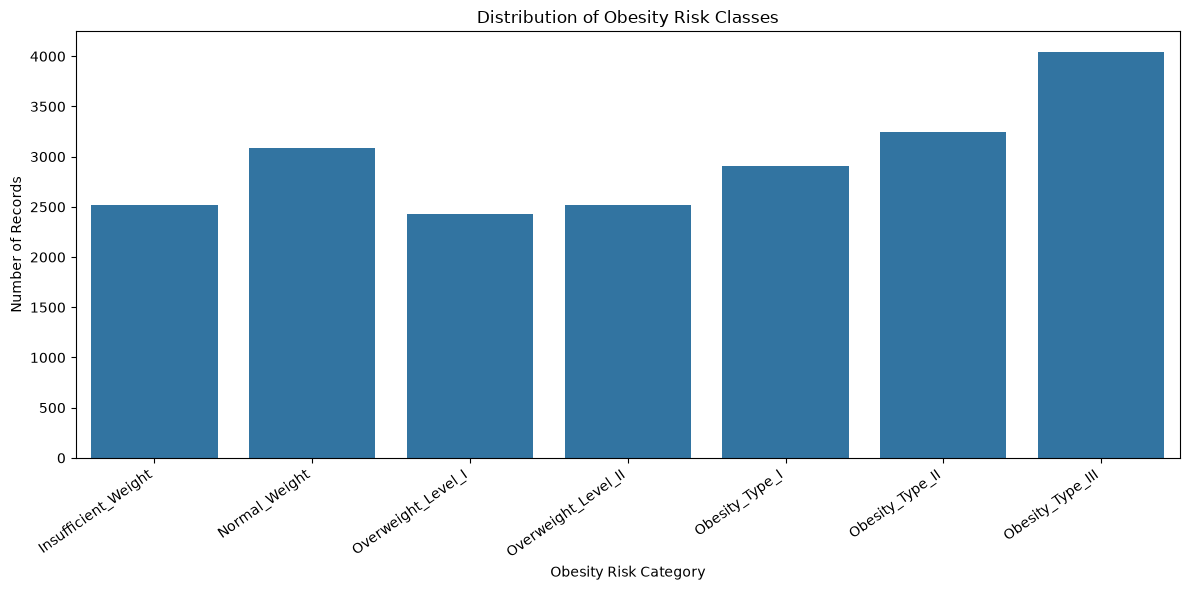

In [38]:
plt.figure(figsize=(12, 6))

sns.countplot(
    data=df,
    x=target_column,
    order=class_order,
)

plt.title("Distribution of Obesity Risk Classes")
plt.xlabel("Obesity Risk Category")
plt.ylabel("Number of Records")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()

In [39]:
identifier_column = "id"
target_column = "NObeyesdad"

numerical_features = [
    column
    for column in df.select_dtypes(include="number").columns
    if column != identifier_column
]

categorical_features = [
    column
    for column in df.select_dtypes(exclude="number").columns
    if column != target_column
]

print("Identifier:", identifier_column)
print("Target:", target_column)

print("\nNumerical features:")
print(numerical_features)

print("\nCategorical features:")
print(categorical_features)

print("\nNumber of numerical features:", len(numerical_features))
print("Number of categorical features:", len(categorical_features))
print("Total predictive features:", len(numerical_features) + len(categorical_features))

Identifier: id
Target: NObeyesdad

Numerical features:
['Age', 'Height', 'Weight', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE']

Categorical features:
['Gender', 'family_history_with_overweight', 'FAVC', 'CAEC', 'SMOKE', 'SCC', 'CALC', 'MTRANS']

Number of numerical features: 8
Number of categorical features: 8
Total predictive features: 16


In [40]:
numerical_summary = (
    df[numerical_features]
    .describe()
    .T
    .round(3)
)

numerical_summary

,count,mean,std,min,25%,50%,75%,max
Age,20758.0,23.842,5.688,14.00,20.000,22.815,26.000,61.000
Height,20758.0,1.700,0.087,1.45,1.632,1.700,1.763,1.976
Weight,20758.0,87.888,26.379,39.00,66.000,84.065,111.601,165.057
FCVC,20758.0,2.446,0.533,1.00,2.000,2.394,3.000,3.000
NCP,20758.0,2.761,0.705,1.00,3.000,3.000,3.000,4.000
CH2O,20758.0,2.029,0.608,1.00,1.792,2.000,2.550,3.000
FAF,20758.0,0.982,0.838,0.00,0.008,1.000,1.587,3.000
TUE,20758.0,0.617,0.602,0.00,0.000,0.574,1.000,2.000


In [42]:
validity_checks = {
    "Non-positive age": (df["Age"] <= 0).sum(),
    "Non-positive height": (df["Height"] <= 0).sum(),
    "Non-positive weight": (df["Weight"] <= 0).sum(),
    "FCVC outside 1-3": (~df["FCVC"].between(1, 3)).sum(),
    "NCP outside 1-4": (~df["NCP"].between(1, 4)).sum(),
    "CH2O outside 1-3": (~df["CH2O"].between(1, 3)).sum(),
    "FAF outside 0-3": (~df["FAF"].between(0, 3)).sum(),
    "TUE outside 0-2": (~df["TUE"].between(0, 2)).sum(),
}

validity_summary = pd.Series(
    validity_checks,
    name="Invalid record count",
)

validity_summary

Non-positive age       0
Non-positive height    0
Non-positive weight    0
FCVC outside 1-3       0
NCP outside 1-4        0
CH2O outside 1-3       0
FAF outside 0-3        0
TUE outside 0-2        0
Name: Invalid record count, dtype: int64

In [43]:
for column in categorical_features:
    unique_values = sorted(
        df[column]
        .dropna()
        .unique()
        .tolist()
    )

    print(f"{column}:")
    print(unique_values)
    print()

Gender:
['Female', 'Male']

family_history_with_overweight:
['no', 'yes']

FAVC:
['no', 'yes']

CAEC:
['Always', 'Frequently', 'Sometimes', 'no']

SMOKE:
['no', 'yes']

SCC:
['no', 'yes']

CALC:
['Frequently', 'Sometimes', 'no']

MTRANS:
['Automobile', 'Bike', 'Motorbike', 'Public_Transportation', 'Walking']



In [44]:
text_columns = categorical_features + [target_column]

whitespace_issues = pd.Series(
    {
        column: (
            df[column].astype(str)
            != df[column].astype(str).str.strip()
        ).sum()
        for column in text_columns
    },
    name="Whitespace issue count",
)

whitespace_issues

Gender                            0
family_history_with_overweight    0
FAVC                              0
CAEC                              0
SMOKE                             0
SCC                               0
CALC                              0
MTRANS                            0
NObeyesdad                        0
Name: Whitespace issue count, dtype: int64